In [1]:
import os
# import sys
# sys.path.append('data')
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# pd.options.plotting.backend = 'plotly'

import cv2
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load data

In [2]:
labels = pd.read_csv('data\\Data_Entry_2017.csv')

with open('data\\train_val_list.txt', 'r') as file:
    train_list = file.read().split('\n')

with open('data\\test_list.txt', 'r') as file:
    test_list = file.read().split('\n')

train = labels.loc[labels['Image Index'].isin(train_list)]
test = labels.loc[labels['Image Index'].isin(test_list)]
assert set(train['Patient ID']).isdisjoint(test['Patient ID'])

train.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
12,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,0.168,NaN


In [3]:
# patient_sus = train.loc[train['Patient Age'] > 100, 'Image Index']
# train.loc[train['Image Index'].isin(patient_sus), :]
# img = cv2.imread('data\\images\\00024680_000.png', 1)
# plt.imshow(img)

In [4]:
#Rename columns
labels.rename(columns={'Follow-up #' : 'follow_up', 'OriginalImage[Width': 'OriginalImageWidth', 'Height]': 'OriginalImageHeight', 'OriginalImagePixelSpacing[x': 'OriginalImagePixelSpacing_x', 'y]': 'OriginalImagePixelSpacing_y'}, inplace=True)
labels.columns = [
    re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col).capitalize().replace(' ', '_')
    for col in labels.columns
]
#Select only relevent columns
labels = labels[['Image_index', 'Finding_labels', 'Follow_up', 'Patient_id', 'Patient_age', 'Patient_gender', 'View_position']]

#Normalize patient_age values after checking on train data
labels.loc[labels['Patient_age'] > 100, 'Patient_age'] = np.nan #Min: 148, Max: 414 yrs old on train data
labels['Patient_age'] = labels.groupby('Patient_id')['Patient_age'].ffill().bfill()

#Unpack finding labels
label_cols = labels['Finding_labels'].str.get_dummies(sep='|')
labels = pd.concat([labels, label_cols], axis=1)
labels['Finding_labels'] = np.where(labels['Finding_labels'] == 'No Finding', 0, 1)
# labels.drop(columns=['Finding_labels'], inplace=True)
labels.rename(columns={'No Finding': 'No_Finding'}, inplace=True)
labels.sort_values(by=['Patient_id', 'Follow_up'], inplace=True)

#Final
train = labels.loc[labels['Image_index'].isin(train_list)].copy()
test = labels.loc[labels['Image_index'].isin(test_list)].copy()
assert set(train['Patient_id']).isdisjoint(test['Patient_id'])

In [5]:
# # Error age 
# checking = train.copy()
# checking['Age_diff'] = checking.groupby('Patient_id')['Patient_age'].diff()

# patient_sus = checking.loc[checking['Age_diff'] < 0, 'Patient_id'].unique()
# patient_sus

## EDA

In [6]:
# Basic dataset information
print('=== Basic Dataset Information ===')
print(f'Total number of images: {len(labels)}')
print(f'Total number of unique patients: {labels['Patient_id'].nunique()}')
print(f'Dataset shape: {labels.shape}')

print('\n=== Train Set Information ===')
print(f'Number of images (train): {len(train)}')
print(f'Number of unique patients (train): {train['Patient_id'].nunique()}')
print(f'Train set shape: {train.shape}')

print('\n=== Test Set Information ===')
print(f'Number of images (test): {len(test)}')
print(f'Number of unique patients (test): {test['Patient_id'].nunique()}')
print(f'Test set shape: {test.shape}')


=== Basic Dataset Information ===
Total number of images: 112120
Total number of unique patients: 30805
Dataset shape: (112120, 22)

=== Train Set Information ===
Number of images (train): 86524
Number of unique patients (train): 28008
Train set shape: (86524, 22)

=== Test Set Information ===
Number of images (test): 25596
Number of unique patients (test): 2797
Test set shape: (25596, 22)


### Patient Demographics

In [7]:
#Unique patient
disease_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]
patient_df = train.copy()
patient_df['Max_distinct_diseases_per_session'] = (patient_df[disease_cols] > 0).sum(axis=1)

patient_df = patient_df.groupby('Patient_id').agg(
    Patient_age = ('Patient_age', 'first'),
    Patient_gender = ('Patient_gender', 'first'),
    Num_images = ('Image_index', 'count'),
    Max_distinct_diseases_per_session = ('Max_distinct_diseases_per_session', 'max'),
    **{d: (d, 'sum') for d in disease_cols}
).reset_index()

patient_df['Max_distinct_diseases_per_patient'] = (patient_df[disease_cols] > 0).sum(axis=1)

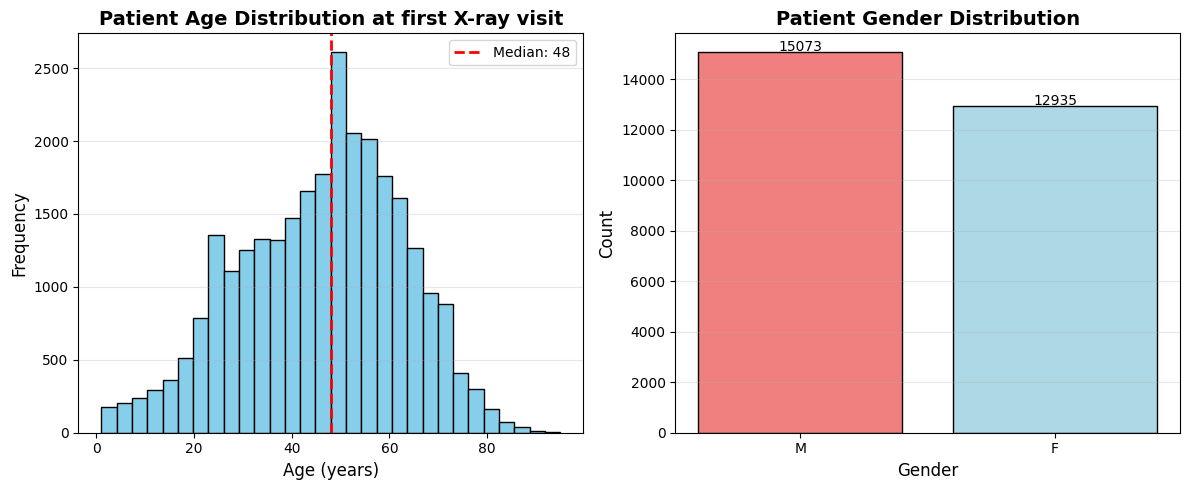

=== Age statistics ===
 count    28008.000000
mean        46.117895
std         16.666849
min          1.000000
25%         34.000000
50%         48.000000
75%         58.000000
max         95.000000
Name: Patient_age, dtype: float64

=== Gender distribution === 
 Patient_gender
M    15073
F    12935
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution at first X-ray visit
ages = patient_df['Patient_age'].dropna()
axes[0].hist(ages, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Patient Age Distribution at first X-ray visit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
if len(ages) > 0:
    median_age = ages.median()
    axes[0].axvline(median_age, color='red', linestyle='--', linewidth=2, label=f'Median: {median_age:.0f}')
    axes[0].legend()

# Gender distribution
gender_counts = patient_df['Patient_gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['lightcoral', 'lightblue'], edgecolor='black')
axes[1].set_title('Patient Gender Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 40, str(v), ha='center')

plt.tight_layout()
plt.show()

print('=== Age statistics ===\n', ages.describe())
print('\n=== Gender distribution === \n', gender_counts)

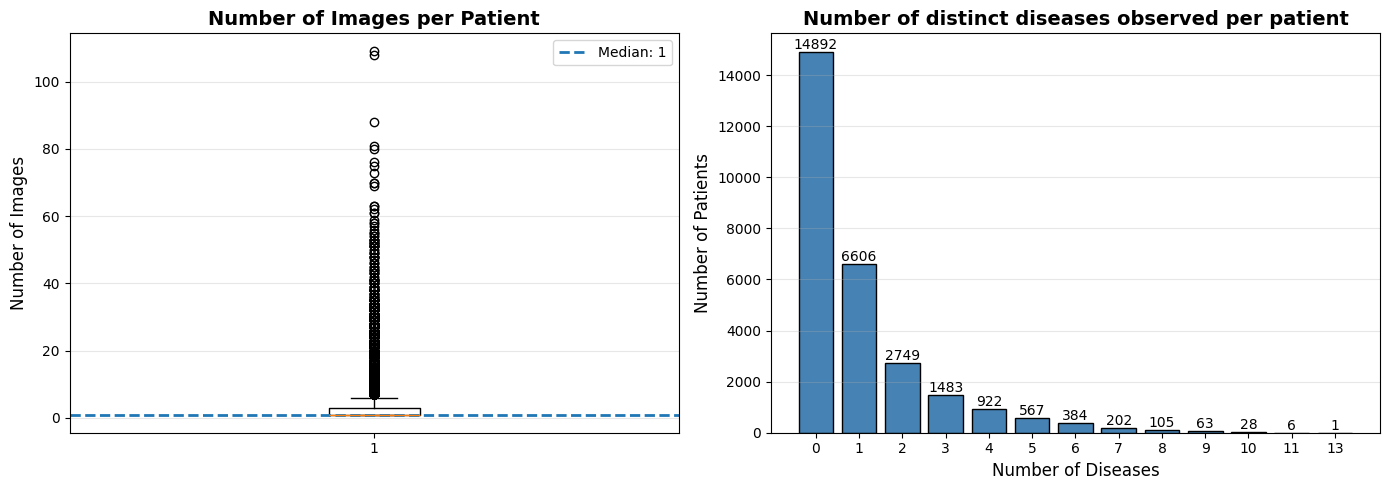

=== Number of images per patient ===
count    28008.000000
mean         3.089260
std          5.003619
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        109.000000
Name: Num_images, dtype: float64

=== Number of distinct diseases observed per patient ===
count    28008.000000
mean         1.019709
std          1.580864
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         13.000000
Name: Max_distinct_diseases_per_patient, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Number of images per patient
num_images = patient_df['Num_images'].dropna()

axes[0].boxplot(num_images)
axes[0].set_title('Number of Images per Patient', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

if len(num_images) > 0:
    median_images = num_images.median()
    axes[0].axhline(median_images, linestyle='--', linewidth=2, label=f'Median: {median_images:.0f}')
    axes[0].legend()

#Number of distinct diseases observed per patient
disease_dist = patient_df['Max_distinct_diseases_per_patient'].value_counts().sort_index()

axes[1].bar(disease_dist.index.astype(str), disease_dist.values, color='steelblue', edgecolor='black')
axes[1].set_title('Number of distinct diseases observed per patient', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Diseases', fontsize=12)
axes[1].set_ylabel('Number of Patients', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(disease_dist.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print('=== Number of images per patient ===')
print(patient_df['Num_images'].describe())

print('\n=== Number of distinct diseases observed per patient ===')
print(patient_df['Max_distinct_diseases_per_patient'].describe())


### Disease Distribution

Total number of disease categories: 14


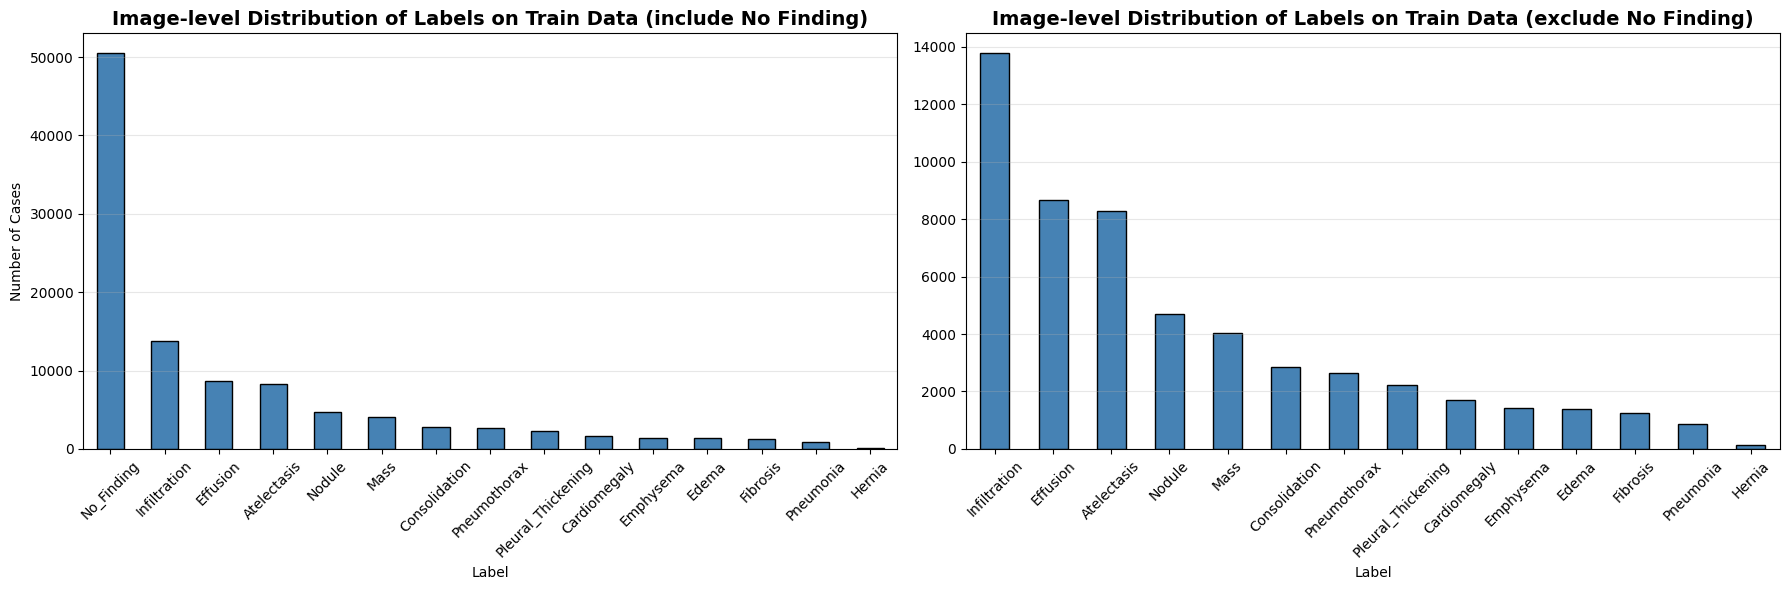


Disease prevalence (%):
No_Finding            58.37
Infiltration          15.93
Effusion              10.01
Atelectasis            9.57
Nodule                 5.44
Mass                   4.66
Consolidation          3.30
Pneumothorax           3.05
Pleural_Thickening     2.59
Cardiomegaly           1.97
Emphysema              1.64
Edema                  1.59
Fibrosis               1.45
Pneumonia              1.01
Hernia                 0.16
dtype: float64


In [10]:
disease_counts = train[disease_cols].sum().sort_values(ascending=False)
print(f'Total number of disease categories: {len(disease_cols)}')
disease_counts_include_nf = train[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Include No Finding
disease_counts_include_nf.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Image-level Distribution of Labels on Train Data (include No Finding)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Number of Cases')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Exclude No Finding
disease_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Image-level Distribution of Labels on Train Data (exclude No Finding)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Percentage of disease labels on train data
disease_pct = (disease_counts_include_nf / len(train) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')

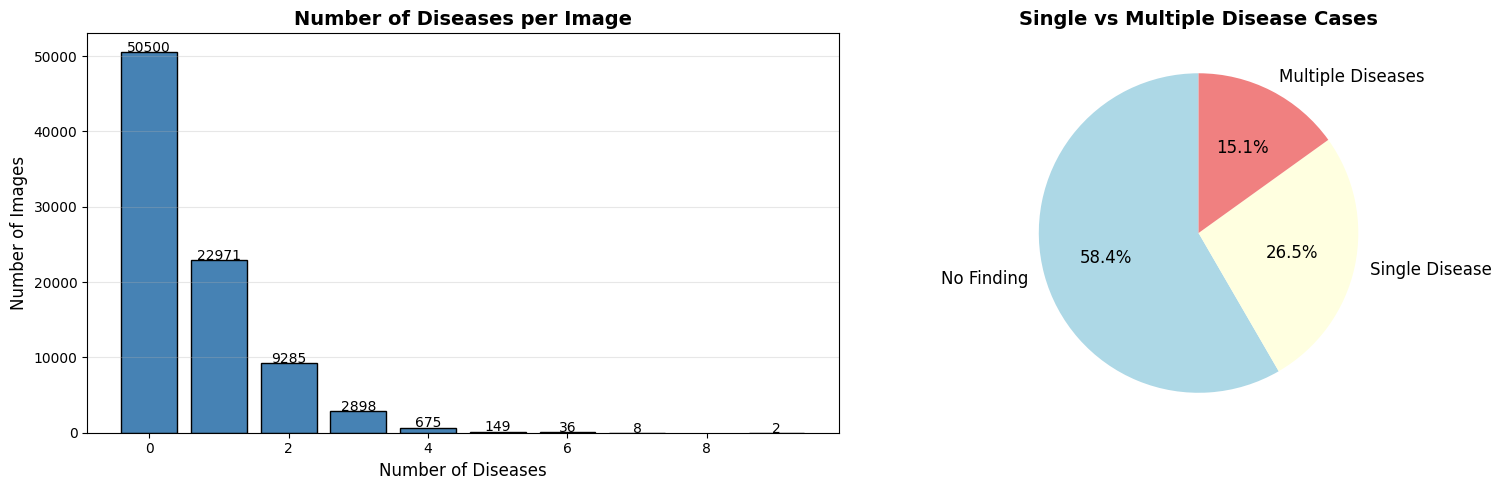

Disease per image statistics:
count    86524.000000
mean         0.623758
std          0.892392
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          9.000000
Name: num_diseases, dtype: float64

No Finding: 50500 (58.37%)
Single disease: 22971 (26.55%)
Multiple diseases: 13053 (15.09%)


In [11]:
# Number of diseases per image (image-level) on train data
train['num_diseases'] = train[disease_cols].sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of number of diseases per image
disease_per_img = train['num_diseases'].value_counts().sort_index()
axes[0].bar(disease_per_img.index, disease_per_img.values, color='steelblue', edgecolor='black')
axes[0].set_title('Number of Diseases per Image', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Diseases', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(disease_per_img.items()):
    axes[0].text(k, v + 20, str(v), ha='center')

# Pie chart for single vs multiple diseases
single_disease = (train['num_diseases'] == 1).sum()
multiple_diseases = (train['num_diseases'] > 1).sum()
no_disease = (train['num_diseases'] == 0).sum()

pie_data = [no_disease, single_disease, multiple_diseases]
pie_labels = ['No Finding', 'Single Disease', 'Multiple Diseases']
colors = ['lightblue', 'lightyellow', 'lightcoral']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=colors, 
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Single vs Multiple Disease Cases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Disease per image statistics:\n{train['num_diseases'].describe()}')
print(f'\nNo Finding: {no_disease} ({no_disease/len(train)*100:.2f}%)')
print(f'Single disease: {single_disease} ({single_disease/len(train)*100:.2f}%)')
print(f'Multiple diseases: {multiple_diseases} ({multiple_diseases/len(train)*100:.2f}%)')

train.drop(columns=['num_diseases'], inplace=True)

### Disease Co-occurrence Heatmap


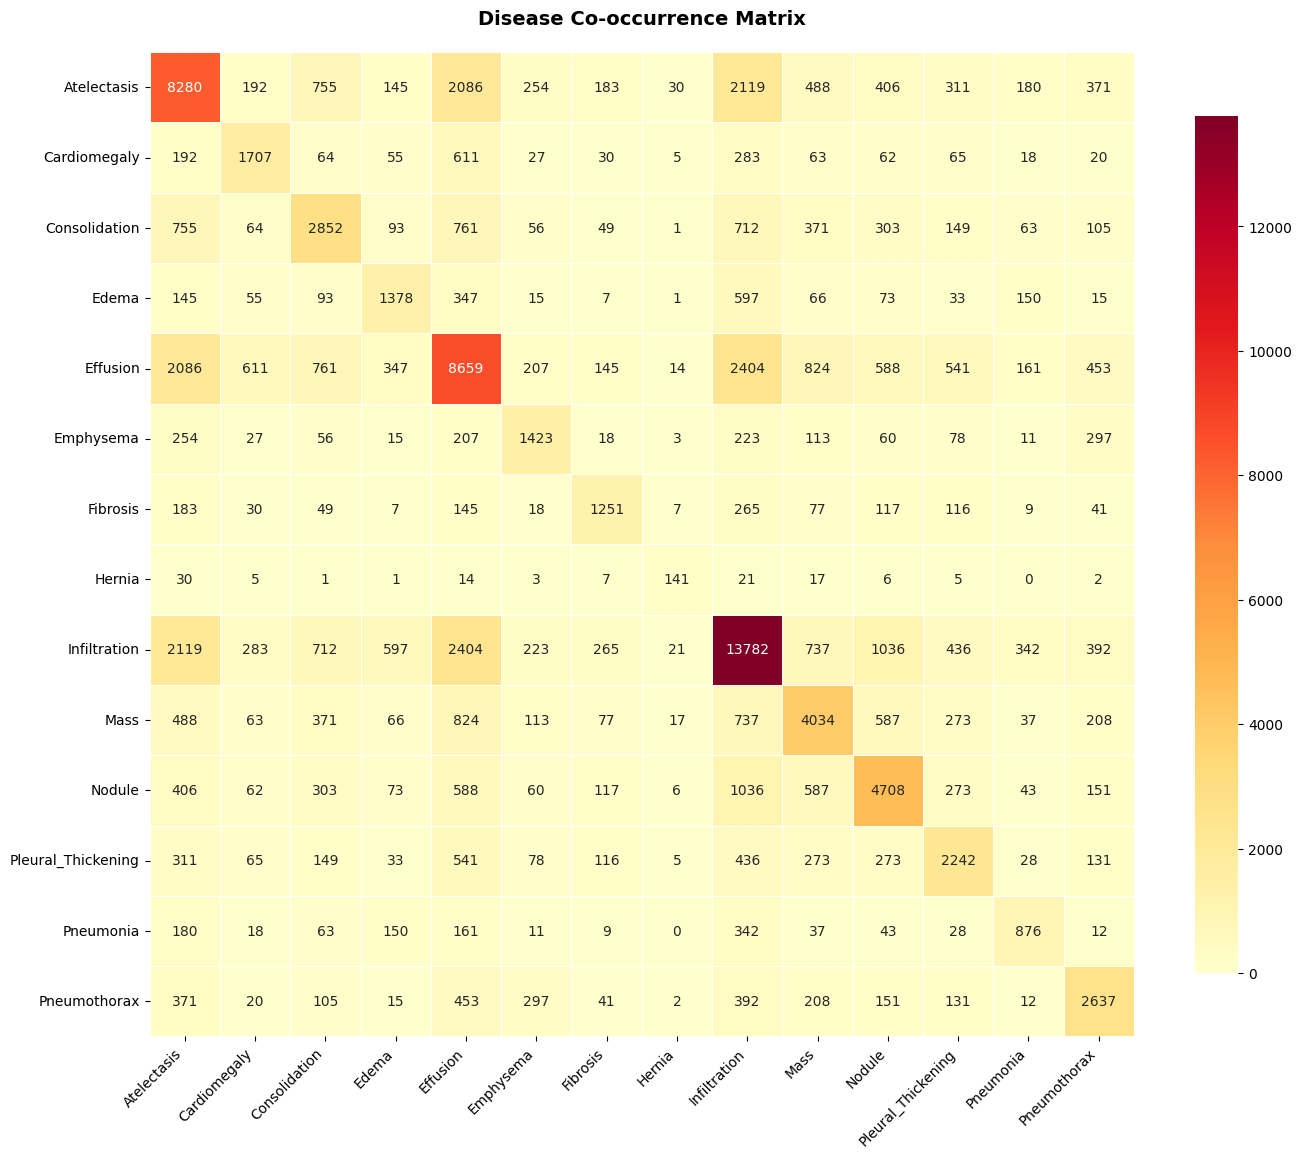

In [12]:
# Calculate disease co-occurrence matrix
cooccurrence = train[disease_cols].T.dot(train[disease_cols])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Disease Co-occurrence Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Multivariate Analysis


#### Age Distribution by Disease


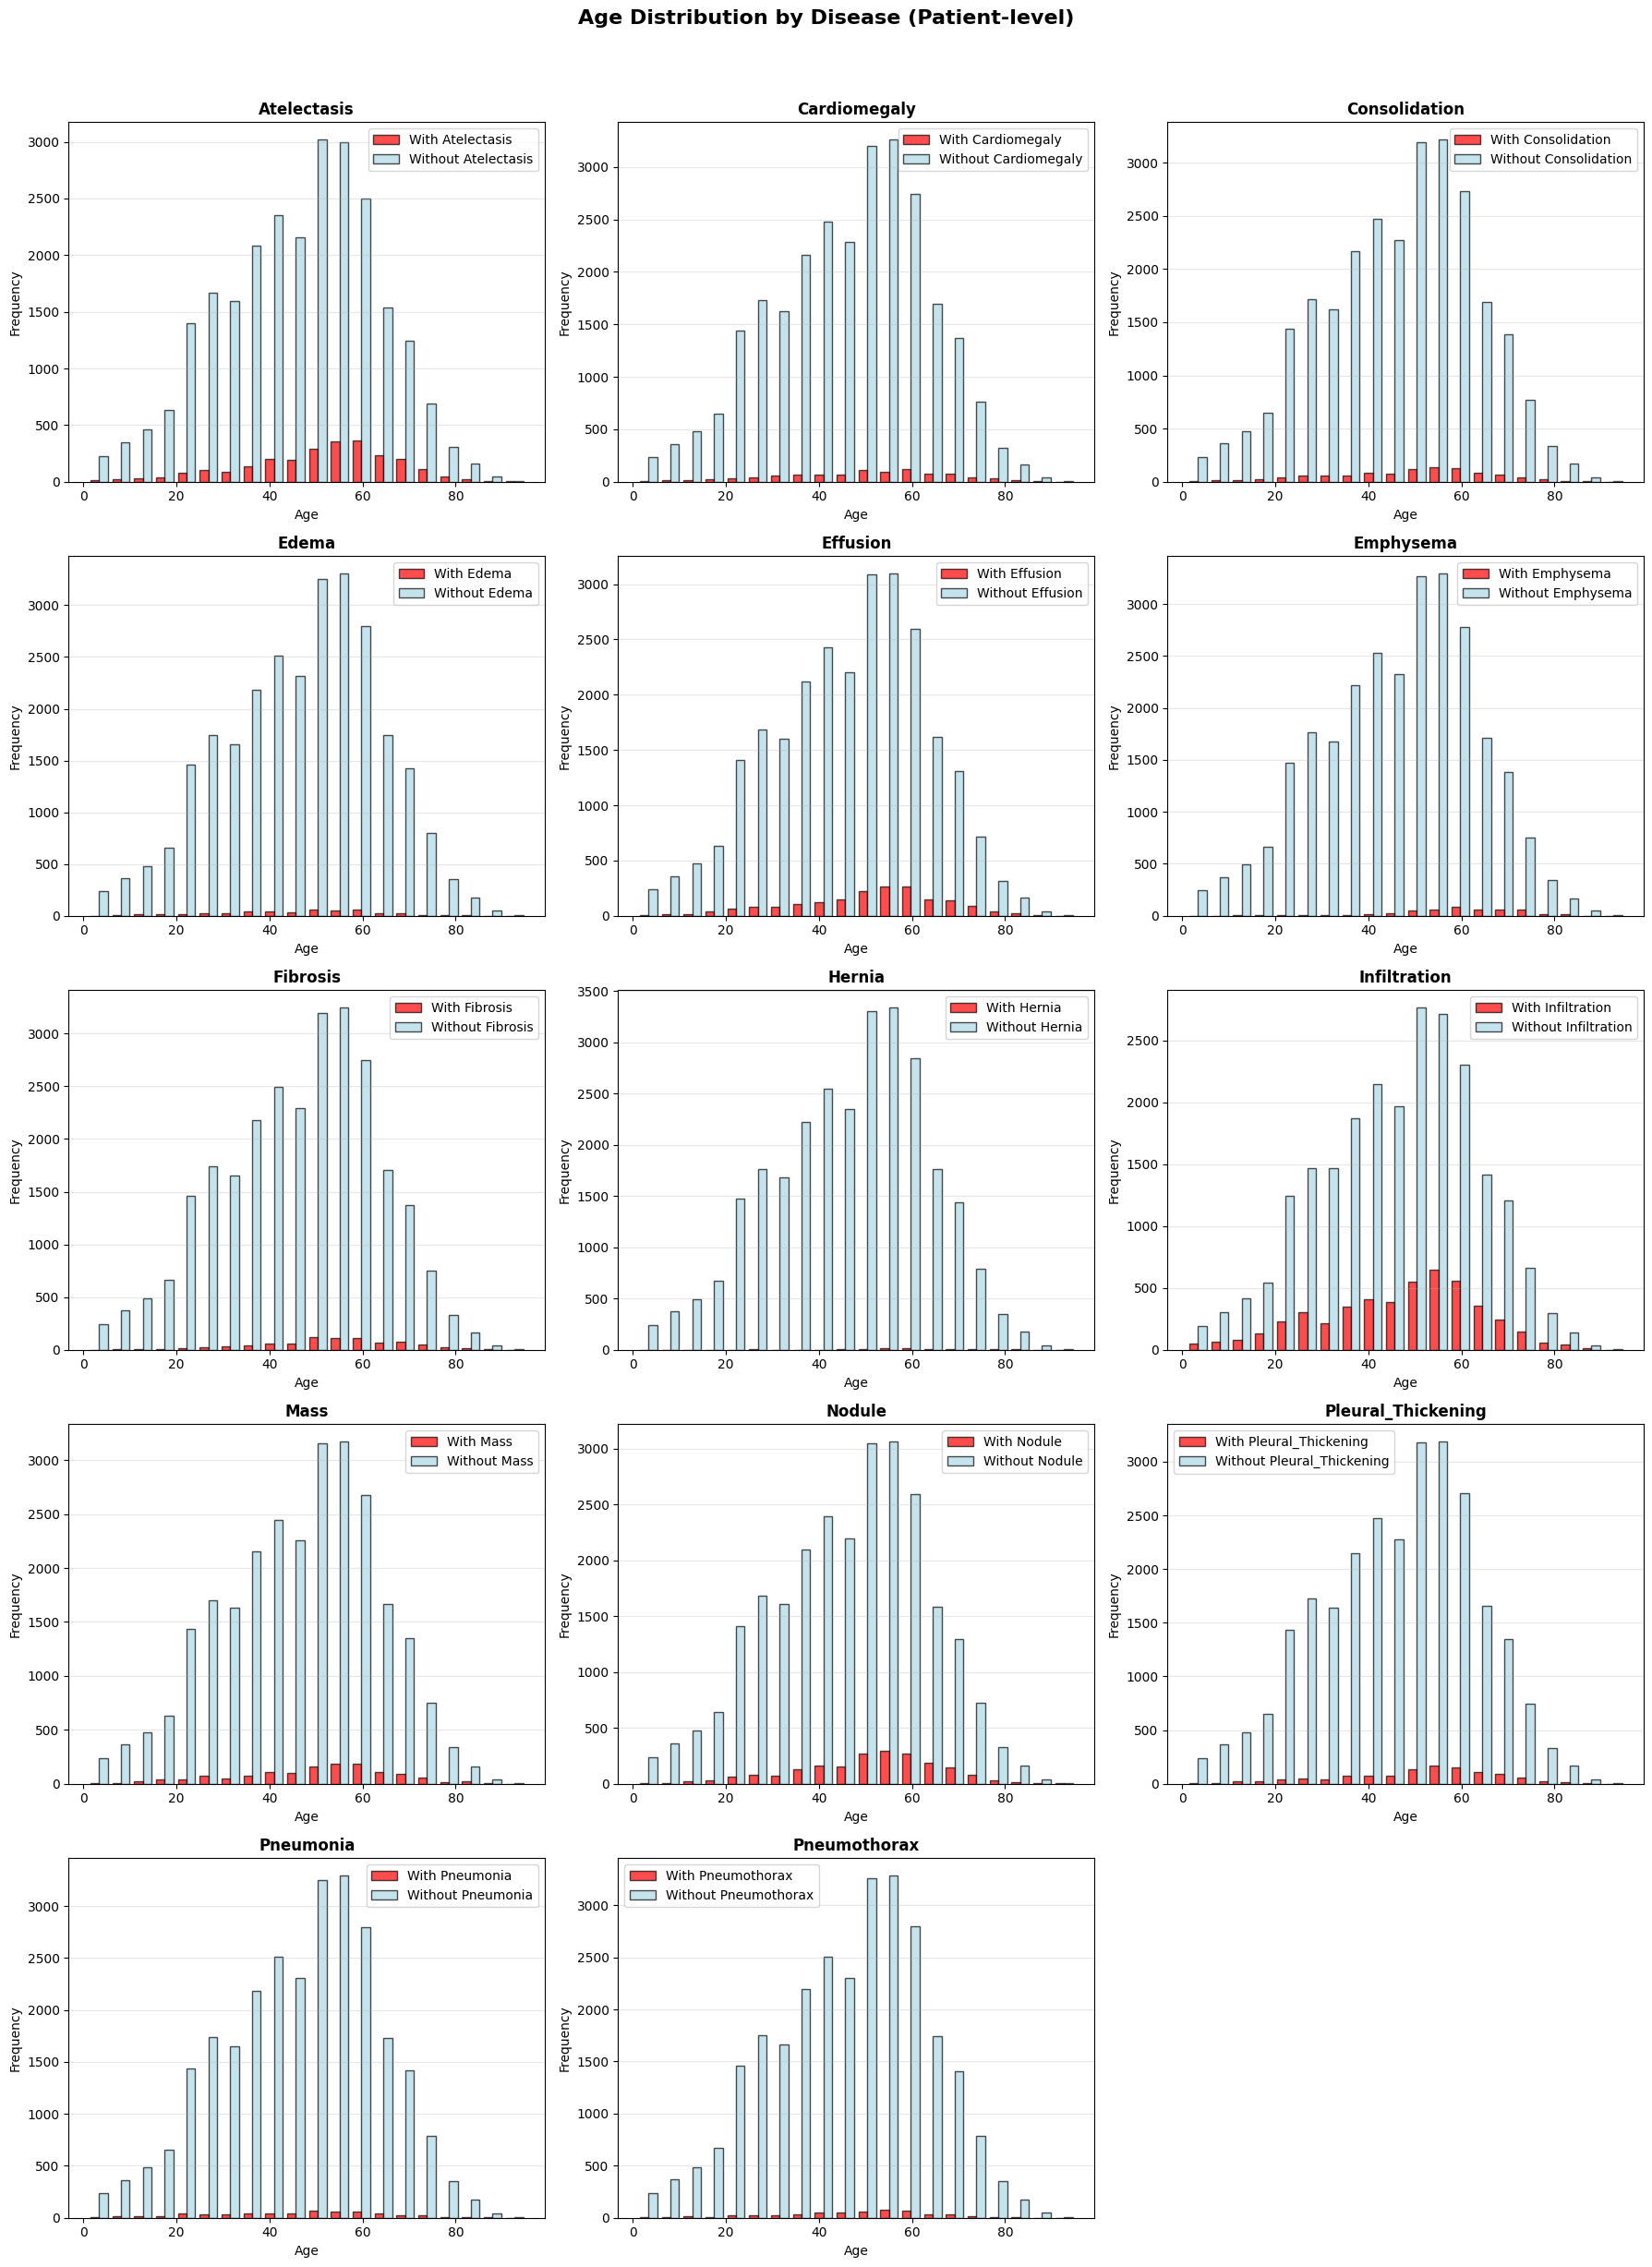

Average age by disease:
Atelectasis: 51.0 years
Cardiomegaly: 49.8 years
Consolidation: 48.7 years
Edema: 46.2 years
Effusion: 50.7 years
Emphysema: 58.4 years
Fibrosis: 53.7 years
Hernia: 61.1 years
Infiltration: 47.0 years
Mass: 49.9 years
Nodule: 50.8 years
Pleural_Thickening: 51.3 years
Pneumonia: 45.8 years
Pneumothorax: 48.8 years


In [13]:
plt.figure(figsize=(18, 25))

for i, disease in enumerate(disease_cols, 1):
    plt.subplot(5, 3, i)
    
    age_with = patient_df.loc[(patient_df[disease] == 1), 'Patient_age']
    age_without = patient_df.loc[~(patient_df[disease] == 1), 'Patient_age']

    plt.hist([age_with, age_without], bins=20, label=[f'With {disease}', f'Without {disease}'], 
             color=['red', 'lightblue'], alpha=0.7, edgecolor='black'
    )
    plt.title(disease, fontsize=12, fontweight='bold')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.suptitle('Age Distribution by Disease (Patient-level)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Average age by disease:')
for disease in disease_cols:
    disease_mask = patient_df[disease] == 1
    avg_age = patient_df.loc[disease_mask, 'Patient_age'].mean()
    print(f'{disease}: {avg_age:.1f} years')

#### Gender Distribution by Disease

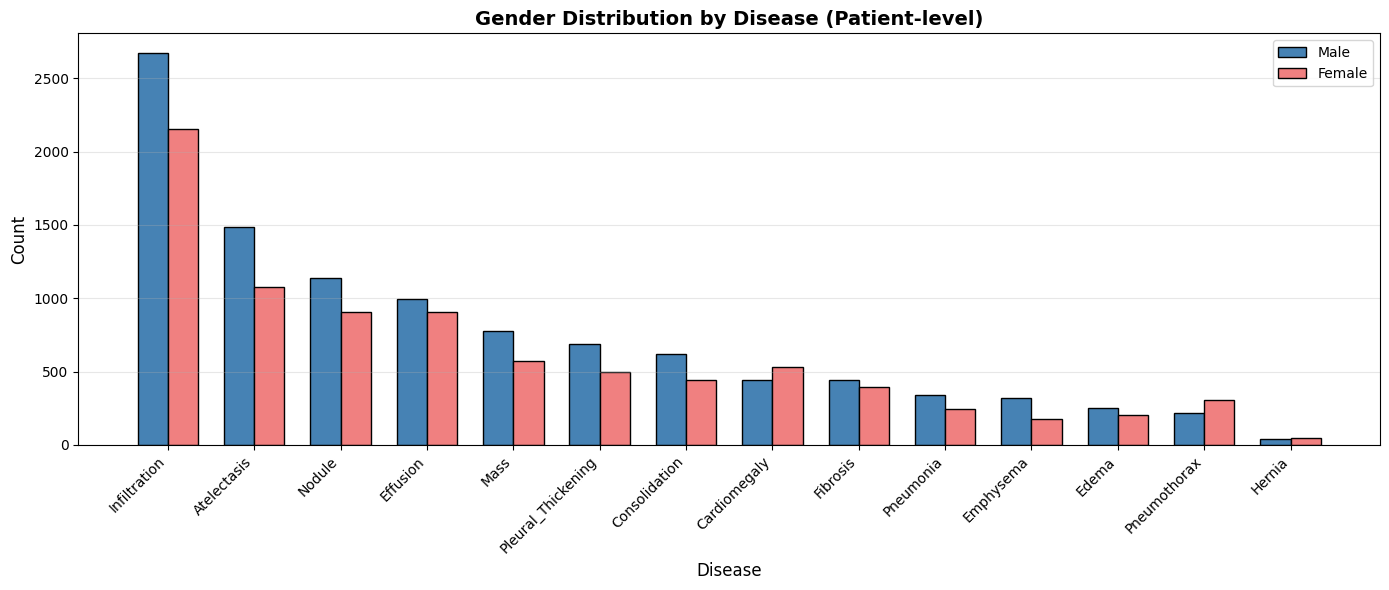

               Disease  Male  Female
0         Infiltration  2672    2156
1          Atelectasis  1483    1073
2               Nodule  1138     903
3             Effusion   992     903
4                 Mass   777     569
5   Pleural_Thickening   687     497
6        Consolidation   620     444
7         Cardiomegaly   444     532
8             Fibrosis   442     397
9            Pneumonia   338     248
10           Emphysema   318     175
11               Edema   249     206
12        Pneumothorax   214     308
13              Hernia    38      45


In [14]:
gender_disease_data = []

for disease in disease_cols:
    male_count = patient_df[(patient_df[disease] == 1) & (patient_df['Patient_gender'] == 'M')].shape[0]
    female_count = patient_df[(patient_df[disease] == 1) & (patient_df['Patient_gender'] == 'F')].shape[0]
    gender_disease_data.append({'Disease': disease, 'Male': male_count, 'Female': female_count})
gender_df = pd.DataFrame(gender_disease_data).sort_values(by='Male',ascending=False).reset_index(drop=True)

x = np.arange(len(gender_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, gender_df['Male'], width, label='Male', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, gender_df['Female'], width, label='Female', color='lightcoral', edgecolor='black')

ax.set_title('Gender Distribution by Disease (Patient-level)', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(gender_df['Disease'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(gender_df)